In [1]:
import fiesta
import glob
#from fiesta.surrogates import download_recommended_surrogates
#download_recommended_surrogates()

from survey_sim import DetectionCriteria

from survey_sim import FixedBu2026KilonovaPopulation, SimulationPipeline, load_ztf_survey
from survey_sim import Bu2026KilonovaPopulation
from survey_sim.fiesta_model import FiestaKNModel
from contextlib import redirect_stdout
import io
import math
# from fiesta.surrogates import download_recommended_surrogates; download_recommended_surrogates()

import numpy as np

import matplotlib.pyplot as plt

from survey_sim.fiesta_model import FiestaKNModel

from survey_sim import (
    FixedBu2026KilonovaPopulation,
    DetectionCriteria,
    SimulationPipeline,
    load_ztf_survey,
)

from survey_sim.serialization import save_result, load_result

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/tbarna/anaconda3/envs/surveysim/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/tbarna/anaconda3/envs/surveysim/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 354, in initialize
    c_api = xb.register_plugin(
            ^^^^^^^^^^^^^^^^^^^
  File "/home/tbarna/anaconda3/envs/surveysim/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 644, in register_plugin
    c_api = xla_client.load_pjrt_plugin_dynamically(plugin_name, library_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tbarna/anaconda3/envs/surveysim/lib/python3.11/site-packages/jaxlib/xla_client.py", line 117, in load_pjrt_plugin_dynamically
    return _xla.load_pjrt_plugin(plugin_name, library_path, c_api=None)
         

In [2]:
import json
import pandas as pd
from pathlib import Path
from json import JSONDecoder

def extract_parameter_space(directory_path):
    path = Path(directory_path)
    all_detected_sources = []
    
    # Custom decoder to handle concatenated JSON objects in a single file
    decoder = JSONDecoder()

    for json_file in path.glob('*.json'):
        with open(json_file, 'r') as f:
            content = f.read().strip()
            
            if not content:
                continue

            pos = 0
            while pos < len(content):
                try:
                    # Decode the next JSON object starting at the current position
                    data, next_pos = decoder.raw_decode(content[pos:])
                    
                    # Ensure data is a dictionary before checking for keys
                    if isinstance(data, dict) and 'detected_sources' in data:
                        for source in data['detected_sources']:
                            source_data = source.get('true_params', {}).copy()
                            source_data['z'] = source.get('z')
                            source_data['t_exp'] = source.get('t_exp')
                            source_data['source_file'] = json_file.name
                            all_detected_sources.append(source_data)
                    
                    # Move the position forward, ignoring any whitespace between objects
                    pos += next_pos
                    while pos < len(content) and content[pos].isspace():
                        pos += 1
                        
                except json.JSONDecodeError as e:
                    print(f"⚠️ Skipping unparseable section in {json_file.name}")
                    print(f"   Error: {e}")
                    break

    return pd.DataFrame(all_detected_sources)

# Example usage:
df_vary = extract_parameter_space('./results/marathon/Bu2026Vary')
display(df_vary.describe())

df_fixed = extract_parameter_space('./results/marathon/Bu2026Fixed')
display(df_fixed.describe())

df_metzger = extract_parameter_space('./results/marathon/Metzger')
display(df_metzger.describe())

,Ye_wind,log10_mej_dyn,inclination_EM,v_ej_dyn,Ye_dyn,v_ej_wind,log10_mej_wind,z,t_exp
count,9.840000e+03,9.840000e+03,9840.000000,9.840000e+03,9840.00,9.840000e+03,9.840000e+03,9840.000000,9840.000000
mean,3.500000e-01,-1.700000e+00,0.591285,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.038106,59169.149343
std,5.551397e-17,2.220559e-16,0.338785,2.775699e-17,0.00,1.387849e-17,2.220559e-16,0.010332,947.787130
min,3.500000e-01,-1.700000e+00,0.075363,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.022732,58185.933999
25%,3.500000e-01,-1.700000e+00,0.347997,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.030003,58383.220672
50%,3.500000e-01,-1.700000e+00,0.593461,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.035130,58695.189429
75%,3.500000e-01,-1.700000e+00,0.804577,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.050192,60096.751615
max,3.500000e-01,-1.700000e+00,1.298621,2.000000e-01,0.15,1.000000e-01,-1.100000e+00,0.053896,61015.246602


⚠️ Skipping unparseable section in ztf_1M_msismall_result_2026-08-14_01:32:24.json
   Error: Expecting value: line 1 column 1 (char 0)
⚠️ Skipping unparseable section in ztf_1M_msismall_result_2026-08-14_00:34:15.json
   Error: Expecting value: line 1 column 1 (char 0)


,log10_mej_wind,v_ej_dyn,v_ej_wind,Ye_dyn,Ye_wind,inclination_EM,log10_mej_dyn,z,t_exp
count,1.404380e+05,1.404380e+05,1.404380e+05,1.404380e+05,1.404380e+05,1.404380e+05,1.404380e+05,140438.000000,140438.000000
mean,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.035584,59554.562546
std,2.220454e-16,2.775567e-17,1.387784e-17,2.775567e-17,5.551135e-17,5.551135e-17,2.220454e-16,0.013625,831.843685
min,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.008145,58182.944384
25%,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.027634,58849.015247
50%,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.034069,59674.303310
75%,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.044702,60244.157472
max,-1.100000e+00,2.000000e-01,1.000000e-01,1.500000e-01,3.500000e-01,4.500000e-01,-1.700000e+00,0.088026,61069.803397


,kappa,vej,mej,z,t_exp
count,58115.0,58115.0,5.811500e+04,58115.000000,58115.000000
mean,398.0,0.5,1.260000e-03,0.020011,59674.161975
std,0.0,0.0,2.168423e-19,0.007407,860.335024
min,398.0,0.5,1.260000e-03,0.005614,58272.795388
25%,398.0,0.5,1.260000e-03,0.013720,59032.242934
50%,398.0,0.5,1.260000e-03,0.021396,59457.658414
75%,398.0,0.5,1.260000e-03,0.026208,60467.992788
max,398.0,0.5,1.260000e-03,0.035004,61075.276584


In [3]:
df_vary_param = extract_parameter_space('./results/marathon_random_params/Bu2026Vary')
display(df_vary_param.describe())

df_fixed_param = extract_parameter_space('./results/marathon_random_params/Bu2026Fixed')
display(df_fixed_param.describe())

df_metzger_param = extract_parameter_space('./results/marathon_random_params/Metzger')
display(df_metzger_param.describe())

,Ye_dyn,inclination_EM,v_ej_dyn,log10_mej_dyn,Ye_wind,log10_mej_wind,v_ej_wind,z,t_exp
count,10525.000000,10525.000000,10525.000000,10525.000000,10525.000000,10525.000000,10525.000000,10525.000000,10525.000000
mean,0.174236,0.808388,0.198969,-1.635723,0.315989,-0.803906,0.105186,0.055025,59521.804444
std,0.051600,0.418714,0.084339,0.252189,0.058431,0.277484,0.054878,0.029284,849.193247
min,0.050306,0.024000,0.080356,-1.998611,0.203173,-1.799774,0.030208,0.003088,58178.749725
25%,0.133660,0.449507,0.120049,-1.893611,0.276529,-0.936570,0.050949,0.033690,58692.423143
50%,0.177950,0.791296,0.199308,-1.619804,0.303741,-0.735153,0.101337,0.049699,59675.472922
75%,0.221341,1.177025,0.275222,-1.382379,0.355669,-0.580575,0.150647,0.070596,60211.412231
max,0.249980,1.570343,0.348667,-1.200256,0.449629,-0.501000,0.199403,0.209620,61094.618264


,log10_mej_dyn,v_ej_wind,v_ej_dyn,inclination_EM,Ye_dyn,log10_mej_wind,Ye_wind,z,t_exp
count,20967.000000,20967.000000,20967.000000,20967.000000,20967.000000,20967.000000,20967.000000,20967.000000,20967.000000
mean,-1.617169,0.101324,0.234760,0.447151,0.189854,-0.868949,0.329865,0.051821,59576.537262
std,0.233886,0.047277,0.079779,0.222845,0.049094,0.292143,0.053157,0.023025,831.977032
min,-1.999485,0.030385,0.080383,0.100439,0.050499,-1.785944,0.201807,0.002711,58179.143916
25%,-1.830961,0.058345,0.161391,0.267971,0.165315,-0.982530,0.290023,0.034831,58850.506134
50%,-1.611436,0.099471,0.244769,0.397535,0.194301,-0.838577,0.344124,0.049301,59676.439745
75%,-1.432131,0.142214,0.318207,0.638559,0.229924,-0.619326,0.351982,0.065791,60238.077803
max,-1.200858,0.199858,0.349941,0.898746,0.249751,-0.503346,0.449436,0.176633,61098.685515


,mej,vej,kappa,z,t_exp
count,161176.000000,161176.000000,161176.000000,161176.000000,161176.000000
mean,0.003160,0.647427,299.825170,0.036949,59729.043907
std,0.001178,0.120406,243.175786,0.020627,832.747212
min,0.000512,0.200664,54.038988,0.002810,58181.613141
25%,0.002056,0.570690,100.091207,0.021565,59048.519768
50%,0.003218,0.673489,218.497358,0.032961,59751.226395
75%,0.004226,0.761447,453.668495,0.048612,60477.626740
max,0.004994,0.799295,996.949786,0.184849,61100.610258


In [4]:
from concurrent.futures import ThreadPoolExecutor
import gc

def load_model_results(path_, max_workers=2, batch_size=100, sample_size=None, random_state=None):
    files = sorted(glob.glob(f"{path_}/*.json"))
    total_files = len(files)
    print(f"Found {total_files} files in {path_}")
    if total_files == 0:
        return []

    # Optional random sampling of files
    if sample_size is not None:
        if sample_size <= 0:
            print(f"Requested sample_size={sample_size}. Returning empty result.")
            return []
        if sample_size > total_files:
            print(f"Requested sample_size={sample_size} exceeds available files ({total_files}). Using all available files.")
            sample_size = total_files
        rng = np.random.default_rng(random_state)
        selected_idx = rng.choice(total_files, size=sample_size, replace=False)
        files = [files[i] for i in selected_idx]
        print(f"Randomly selected {len(files)} files for loading.")

    n_files = len(files)

    def _safe_load(file_path):
        try:
            return load_result(file_path)
        except Exception as e:
            print(f"Skipping failed file {file_path}: {e}")
            return None

    workers = max(1, min(max_workers, n_files))
    loaded_results = []

    # Load in batches to avoid large in-flight memory usage
    for i in range(0, n_files, batch_size):
        batch = files[i:i + batch_size]
        if workers == 1:
            batch_loaded = (_safe_load(f) for f in batch)
        else:
            with ThreadPoolExecutor(max_workers=workers) as pool:
                batch_loaded = pool.map(_safe_load, batch)

        for r in batch_loaded:
            if r is not None:
                loaded_results.append(r)

        gc.collect()
        print(f"Loaded {min(i + batch_size, n_files)}/{n_files}")

    return loaded_results

results_Bu2026Fixed = load_model_results("results/marathon/Bu2026Fixed", max_workers=2, batch_size=50, sample_size=500, random_state=42)
results_Bu2026Vary = load_model_results("results/marathon/Bu2026Vary", max_workers=2, batch_size=50, sample_size=500, random_state=42)
results_Metzger = load_model_results("results/marathon/Metzger", max_workers=2, batch_size=50, sample_size=100, random_state=42)

results_Bu2026Fixed_param = load_model_results("results/marathon_random_params/Bu2026Fixed", max_workers=2, batch_size=50, sample_size=500, random_state=42)
results_Bu2026Vary_param = load_model_results("results/marathon_random_params/Bu2026Vary", max_workers=2, batch_size=50, sample_size=500, random_state=42)
results_Metzger_param = load_model_results("results/marathon_random_params/Metzger", max_workers=2, batch_size=50, sample_size=100, random_state=42)

Found 989 files in results/marathon/Bu2026Fixed
Randomly selected 500 files for loading.
Loaded 50/500
Loaded 100/500
Loaded 150/500
Loaded 200/500
Skipping failed file results/marathon/Bu2026Fixed/ztf_1M_msismall_result_2026-08-14_01:32:24.json: Extra data: line 76409 column 4 (char 1728940)
Loaded 250/500
Loaded 300/500
Loaded 350/500
Loaded 400/500
Loaded 450/500
Loaded 500/500
Found 984 files in results/marathon/Bu2026Vary
Randomly selected 500 files for loading.
Loaded 50/500
Loaded 100/500
Loaded 150/500
Loaded 200/500
Loaded 250/500
Loaded 300/500
Loaded 350/500
Loaded 400/500
Loaded 450/500
Loaded 500/500
Found 985 files in results/marathon/Metzger
Randomly selected 100 files for loading.
Loaded 50/100
Loaded 100/100
Found 495 files in results/marathon_random_params/Bu2026Fixed
Requested sample_size=500 exceeds available files (495). Using all available files.
Randomly selected 495 files for loading.
Loaded 50/495
Loaded 100/495
Loaded 150/495
Loaded 200/495
Loaded 250/495
Load

/home/tbarna/anaconda3/envs/surveysim/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


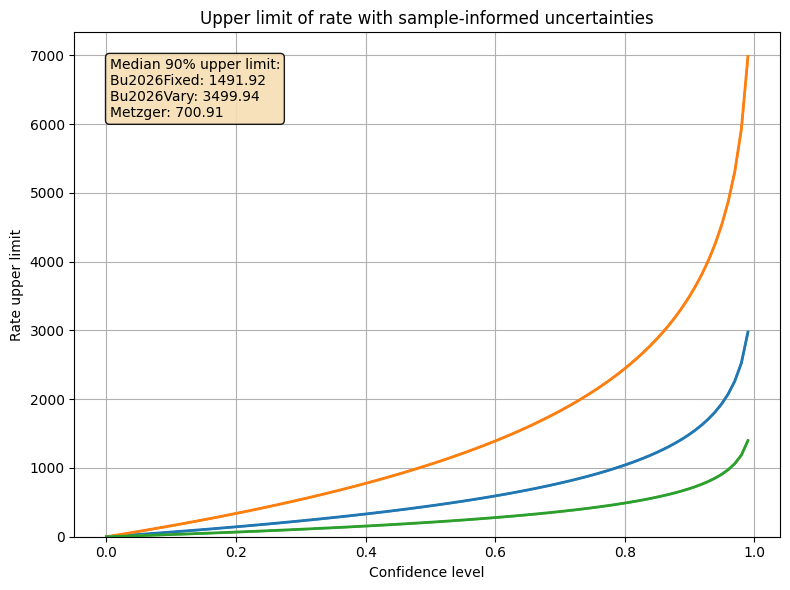

In [5]:
from concurrent.futures import ThreadPoolExecutor
from types import SimpleNamespace

fig, ax = plt.subplots(figsize=(8, 6))
# Precompute once (in parallel) and cache upper_limit(rate_upper) lookups
_percentiles = np.linspace(0, 1, 100)

def _cache_result_upper_limits(result):
    s = result.rate_summaries[0]
    return {float(p): s.upper_limit(float(p)).rate_upper for p in _percentiles}

def _attach_cached_upper_limit(result, cache):
    s = result.rate_summaries[0]
    if hasattr(s, "_orig_upper_limit"):
        return
    s._orig_upper_limit = s.upper_limit

    def _fast_upper_limit(percentile, _cache=cache, _orig=s._orig_upper_limit):
        p = float(percentile)
        if p in _cache:
            return SimpleNamespace(rate_upper=_cache[p])
        out = _orig(p)
        return SimpleNamespace(rate_upper=out.rate_upper)

    s.upper_limit = _fast_upper_limit

def _warm_cache(models):
    if not models:
        return
    workers = min(32, len(models))
    with ThreadPoolExecutor(max_workers=workers) as ex:
        caches = list(ex.map(_cache_result_upper_limits, models))
    for r, c in zip(models, caches):
        _attach_cached_upper_limit(r, c)

for _models in (results_Bu2026Fixed, results_Bu2026Vary, results_Metzger):
    _warm_cache(_models)

# Make each outer plotting loop run once (item variable is unused there)
class _PlotOnceIterable:
    def __init__(self, data):
        self._data = list(data)
        self._iter_calls = 0

    def __iter__(self):
        self._iter_calls += 1
        if self._iter_calls == 1:
            return iter(self._data[:1])  # outer loop: single pass
        return iter(self._data)          # inner loops + later usage: full data

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        return self._data[i]

results_Bu2026Fixed = _PlotOnceIterable(results_Bu2026Fixed)
results_Bu2026Vary = _PlotOnceIterable(results_Bu2026Vary)
results_Metzger = _PlotOnceIterable(results_Metzger)

for item in results_Bu2026Fixed:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
        [
            result.rate_summaries[0].upper_limit(percentile).rate_upper
            for percentile in np.linspace(0, 1, 100)
        ]
        for result in results_Bu2026Fixed
    ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C0", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C0", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C0", alpha=0.12, label="95% interval")
    
    
for item in results_Bu2026Vary:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
            [
                result.rate_summaries[0].upper_limit(percentile).rate_upper
                for percentile in np.linspace(0, 1, 100)
            ]
            for result in results_Bu2026Vary
        ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C1", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C1", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C1", alpha=0.12, label="95% interval")
    
for item in results_Metzger:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
            [
                result.rate_summaries[0].upper_limit(percentile).rate_upper
                for percentile in np.linspace(0, 1, 100)
            ]
            for result in results_Metzger
        ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C2", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C2", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C2", alpha=0.12, label="95% interval")
    

## inlay single text box that lists median 90% upper limit value for each model
median_90_rates = []
for model_ in [results_Bu2026Fixed, results_Bu2026Vary, results_Metzger]:
    median_90_rates.append(np.nanmedian([result.rate_summaries[0].upper_limit(0.90).rate_upper for result in model_]))
textstr = '\n'.join(('Median 90% upper limit:',
                    f'Bu2026Fixed: {median_90_rates[0]:.2f}',
                    f'Bu2026Vary: {median_90_rates[1]:.2f}',
                    f'Metzger: {median_90_rates[2]:.2f}'))
props = {"boxstyle": 'round', "facecolor": 'wheat', "alpha": 0.9}
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
plt.xlabel("Confidence level")
plt.ylabel("Rate upper limit")
plt.title("Upper limit of rate with sample-informed uncertainties")
# plt.legend()
ax.set_ylim(0,)
# ax.set_yscale("log")
plt.tight_layout()
plt.grid()
plt.show()

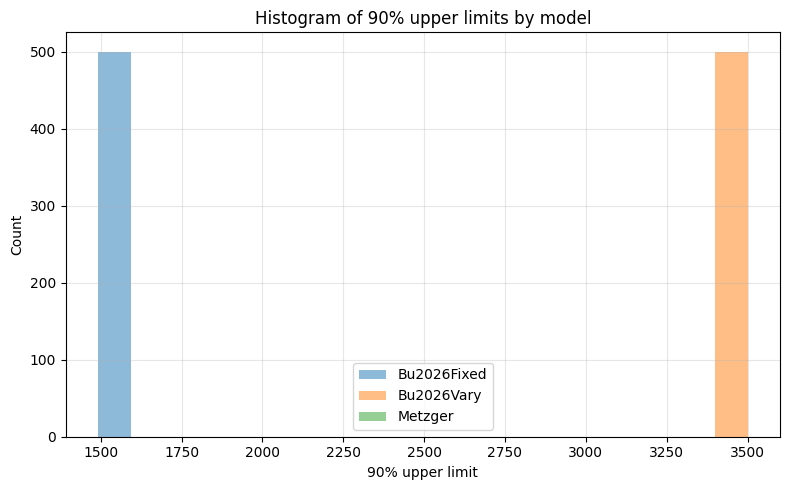

In [6]:
upper_90_fixed = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Fixed], dtype=float)
upper_90_vary = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Vary], dtype=float)
upper_90_metzger = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Metzger], dtype=float)

upper_90_fixed = upper_90_fixed[np.isfinite(upper_90_fixed)]
upper_90_vary = upper_90_vary[np.isfinite(upper_90_vary)]
upper_90_metzger = upper_90_metzger[np.isfinite(upper_90_metzger)]

# all_vals = np.concatenate([upper_90_fixed, upper_90_vary, upper_90_metzger])
all_vals = np.concatenate([upper_90_fixed, upper_90_vary])
bins = np.histogram_bin_edges(all_vals, bins=20)

plt.figure(figsize=(8, 5))
plt.hist(upper_90_fixed, bins=bins, alpha=0.5, color="C0", label="Bu2026Fixed")
plt.hist(upper_90_vary, bins=bins, alpha=0.5, color="C1", label="Bu2026Vary")
plt.hist(upper_90_metzger, bins=bins, alpha=0.5, color="C2", label="Metzger")

plt.xlabel("90% upper limit")
plt.ylabel("Count")
plt.title("Histogram of 90% upper limits by model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

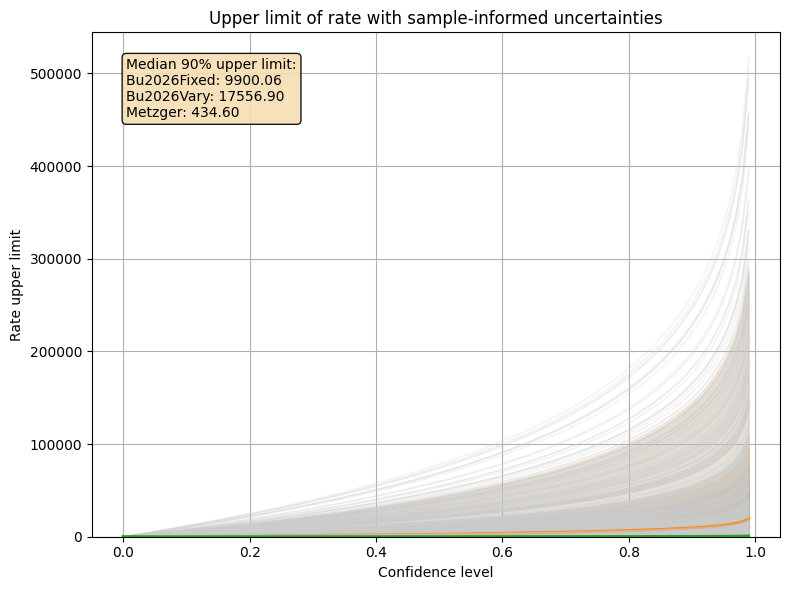

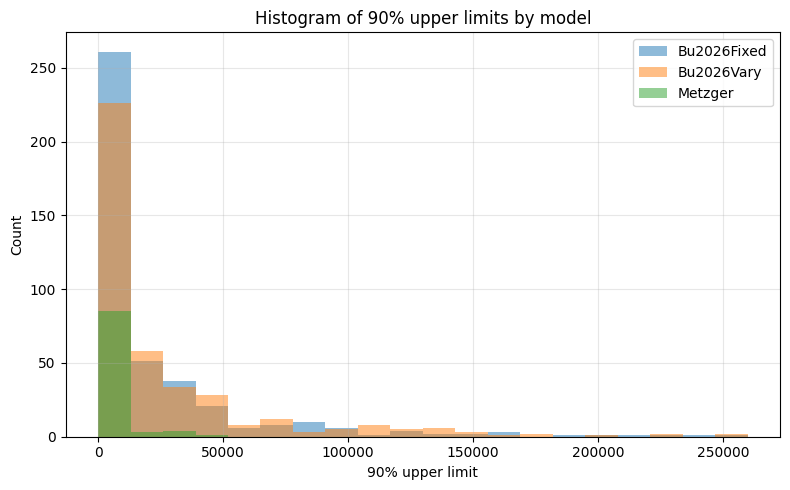

In [7]:
from concurrent.futures import ThreadPoolExecutor
from types import SimpleNamespace

fig, ax = plt.subplots(figsize=(8, 6))
# Precompute once (in parallel) and cache upper_limit(rate_upper) lookups
_percentiles = np.linspace(0, 1, 100)

def _cache_result_upper_limits(result):
    s = result.rate_summaries[0]
    return {float(p): s.upper_limit(float(p)).rate_upper for p in _percentiles}

def _attach_cached_upper_limit(result, cache):
    s = result.rate_summaries[0]
    if hasattr(s, "_orig_upper_limit"):
        return
    s._orig_upper_limit = s.upper_limit

    def _fast_upper_limit(percentile, _cache=cache, _orig=s._orig_upper_limit):
        p = float(percentile)
        if p in _cache:
            return SimpleNamespace(rate_upper=_cache[p])
        out = _orig(p)
        return SimpleNamespace(rate_upper=out.rate_upper)

    s.upper_limit = _fast_upper_limit

def _warm_cache(models):
    if not models:
        return
    workers = min(32, len(models))
    with ThreadPoolExecutor(max_workers=workers) as ex:
        caches = list(ex.map(_cache_result_upper_limits, models))
    for r, c in zip(models, caches):
        _attach_cached_upper_limit(r, c)

for _models in (results_Bu2026Fixed_param, results_Bu2026Vary_param, results_Metzger_param):
    _warm_cache(_models)

# Make each outer plotting loop run once (item variable is unused there)
class _PlotOnceIterable:
    def __init__(self, data):
        self._data = list(data)
        self._iter_calls = 0

    def __iter__(self):
        self._iter_calls += 1
        if self._iter_calls == 1:
            return iter(self._data[:1])  # outer loop: single pass
        return iter(self._data)          # inner loops + later usage: full data

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        return self._data[i]

results_Bu2026Fixed_param = _PlotOnceIterable(results_Bu2026Fixed_param)
results_Bu2026Vary_param = _PlotOnceIterable(results_Bu2026Vary_param)
results_Metzger_param = _PlotOnceIterable(results_Metzger_param)

for item in results_Bu2026Fixed_param:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
        [
            result.rate_summaries[0].upper_limit(percentile).rate_upper
            for percentile in np.linspace(0, 1, 100)
        ]
        for result in results_Bu2026Fixed_param
    ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C0", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C0", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C0", alpha=0.12, label="95% interval")
    
    
for item in results_Bu2026Vary_param:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
            [
                result.rate_summaries[0].upper_limit(percentile).rate_upper
                for percentile in np.linspace(0, 1, 100)
            ]
            for result in results_Bu2026Vary_param
        ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C1", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C1", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C1", alpha=0.12, label="95% interval")
    
for item in results_Metzger_param:
    # print(item.rate_summaries[0].upper_limit(0.90).rate_upper)
    upper_limits = [
            [
                result.rate_summaries[0].upper_limit(percentile).rate_upper
                for percentile in np.linspace(0, 1, 100)
            ]
            for result in results_Metzger_param
        ]
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan

    confidence = np.linspace(0, 1, ul.shape[1])

    q16 = np.nanpercentile(ul, 16, axis=0)
    q50 = np.nanpercentile(ul, 50, axis=0)
    q84 = np.nanpercentile(ul, 84, axis=0)
    q025 = np.nanpercentile(ul, 2.5, axis=0)
    q975 = np.nanpercentile(ul, 97.5, axis=0)

    for row in ul:
        plt.plot(confidence, row, color="0.8", alpha=0.25, lw=1)

    plt.plot(confidence, q50, color="C2", lw=2, label="Median")
    plt.fill_between(confidence, q16, q84, color="C2", alpha=0.25, label="68% interval")
    plt.fill_between(confidence, q025, q975, color="C2", alpha=0.12, label="95% interval")
    

## inlay single text box that lists median 90% upper limit value for each model
median_90_rates = []
for model_ in [results_Bu2026Fixed_param, results_Bu2026Vary_param, results_Metzger_param]:
    median_90_rates.append(np.nanmedian([result.rate_summaries[0].upper_limit(0.90).rate_upper for result in model_]))
textstr = '\n'.join(('Median 90% upper limit:',
                    f'Bu2026Fixed: {median_90_rates[0]:.2f}',
                    f'Bu2026Vary: {median_90_rates[1]:.2f}',
                    f'Metzger: {median_90_rates[2]:.2f}'))
props = {"boxstyle": 'round', "facecolor": 'wheat', "alpha": 0.9}
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
plt.xlabel("Confidence level")
plt.ylabel("Rate upper limit")
plt.title("Upper limit of rate with sample-informed uncertainties")
# plt.legend()
ax.set_ylim(0,)
# ax.set_yscale("log")
plt.tight_layout()
plt.grid()
plt.show()

upper_90_fixed = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Fixed_param], dtype=float)
upper_90_vary = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Bu2026Vary_param], dtype=float)
upper_90_metzger = np.asarray([r.rate_summaries[0].upper_limit(0.90).rate_upper for r in results_Metzger_param], dtype=float)

upper_90_fixed = upper_90_fixed[np.isfinite(upper_90_fixed)]
upper_90_vary = upper_90_vary[np.isfinite(upper_90_vary)]
upper_90_metzger = upper_90_metzger[np.isfinite(upper_90_metzger)]

# all_vals = np.concatenate([upper_90_fixed, upper_90_vary, upper_90_metzger])
all_vals = np.concatenate([upper_90_fixed, upper_90_vary])
bins = np.histogram_bin_edges(all_vals, bins=20)

plt.figure(figsize=(8, 5))
plt.hist(upper_90_fixed, bins=bins, alpha=0.5, color="C0", label="Bu2026Fixed")
plt.hist(upper_90_vary, bins=bins, alpha=0.5, color="C1", label="Bu2026Vary")
plt.hist(upper_90_metzger, bins=bins, alpha=0.5, color="C2", label="Metzger")

plt.xlabel("90% upper limit")
plt.ylabel("Count")
plt.title("Histogram of 90% upper limits by model")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

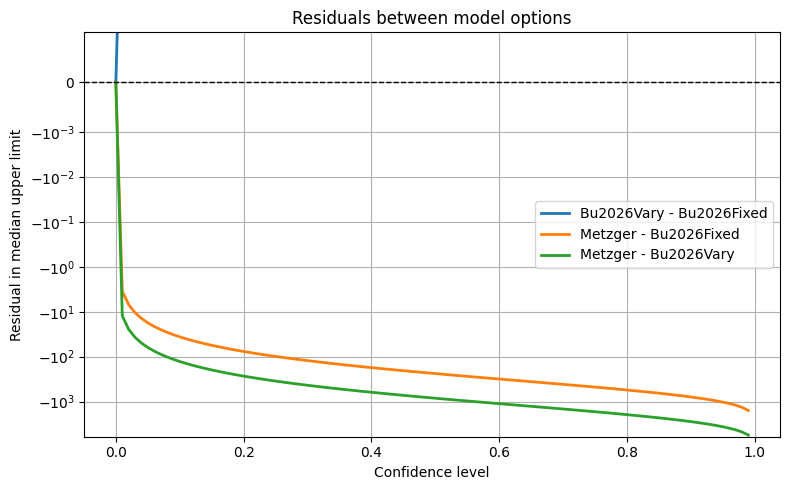

In [8]:
def build_upper_limit_curve(results, n_points=100):
    confidence = np.linspace(0, 1, n_points)
    upper_limits = []
    for result in results:
        upper_limits.append([
            result.rate_summaries[0].upper_limit(p).rate_upper
            for p in confidence
        ])
    ul = np.asarray(upper_limits, dtype=float)
    ul[~np.isfinite(ul)] = np.nan
    return confidence, ul


confidence_fixed, ul_fixed = build_upper_limit_curve(results_Bu2026Fixed)
_, ul_vary = build_upper_limit_curve(results_Bu2026Vary)
_, ul_metzger = build_upper_limit_curve(results_Metzger)

q50_fixed = np.nanpercentile(ul_fixed, 50, axis=0)
q50_vary = np.nanpercentile(ul_vary, 50, axis=0)
q50_metzger = np.nanpercentile(ul_metzger, 50, axis=0)

residuals = [
    ("Bu2026Vary - Bu2026Fixed", q50_vary - q50_fixed),
    ("Metzger - Bu2026Fixed", q50_metzger - q50_fixed),
    ("Metzger - Bu2026Vary", q50_metzger - q50_vary),
]

fig, ax = plt.subplots(figsize=(8, 5))
for label, residual in residuals:
    ax.plot(confidence_fixed, residual, lw=2, label=label)

ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Confidence level")
ax.set_ylabel("Residual in median upper limit")
ax.set_title("Residuals between model options")
ax.grid(True)
ax.legend()
ax.set_yscale("symlog", linthresh=1e-3)
ax.set_ylim(None,1e-3)
plt.tight_layout()
plt.show()

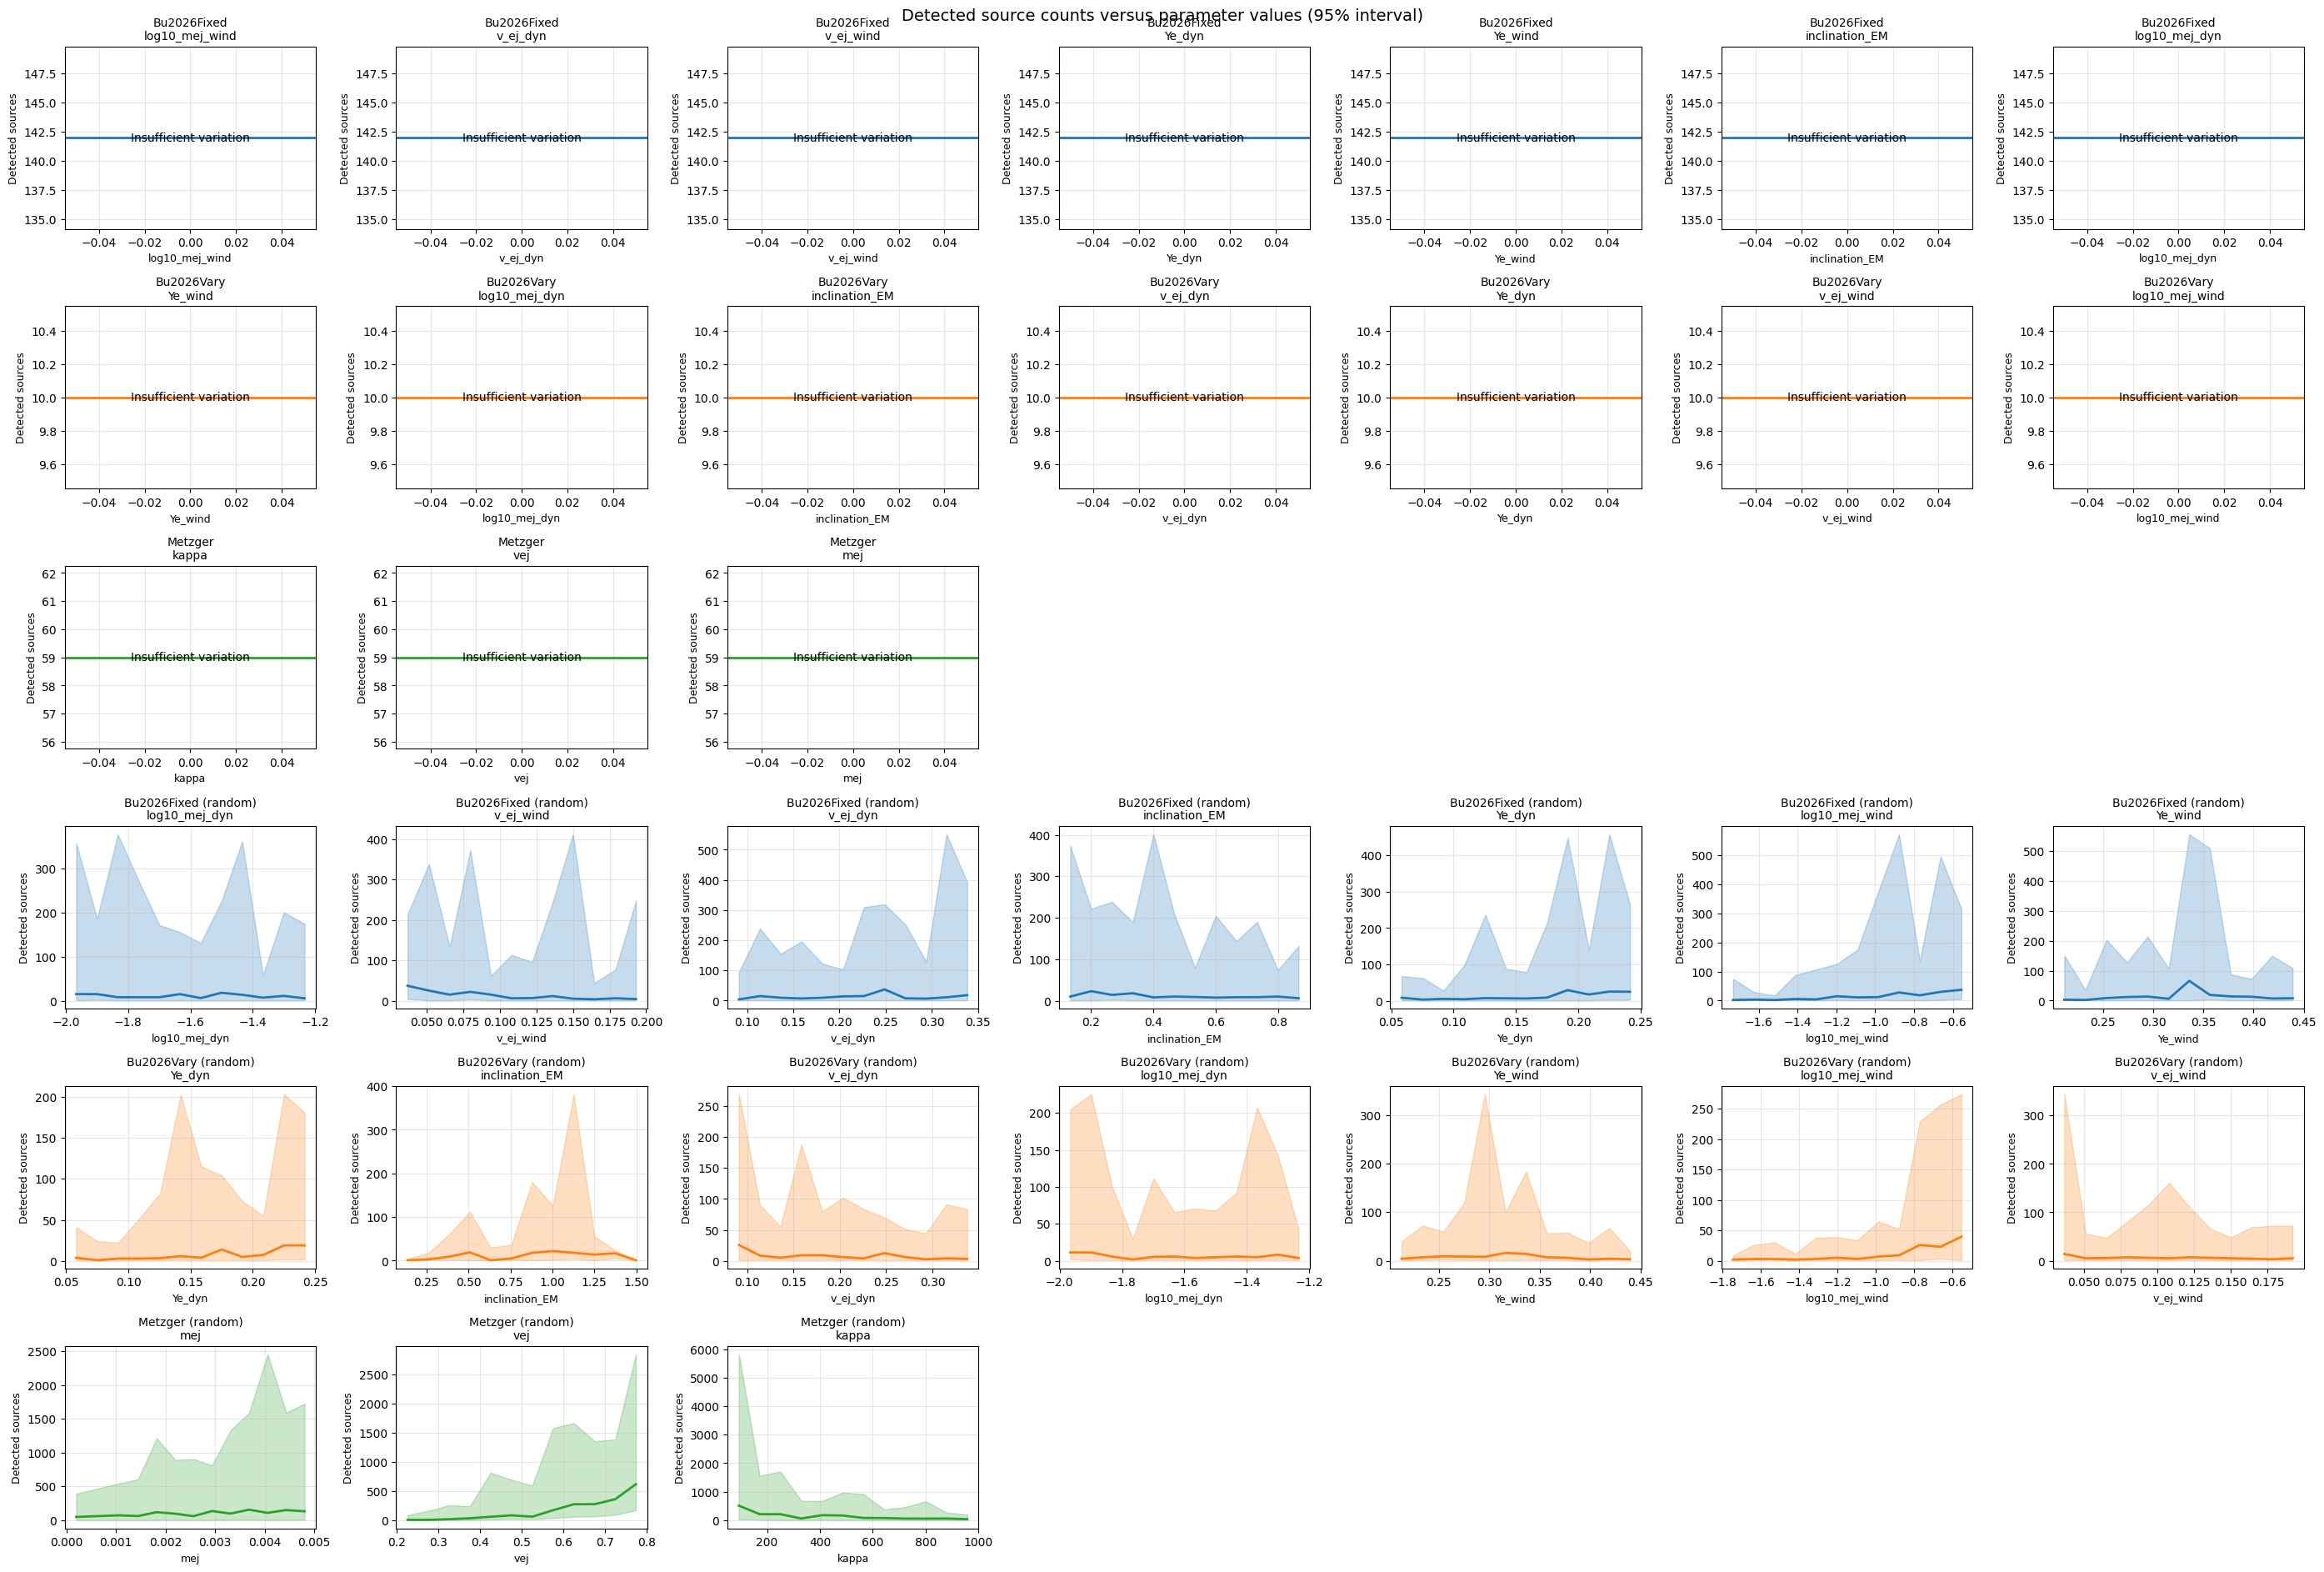

In [13]:
## plots of the distribution of number of detected sources at 95 percent confidence interval as a function of the various parameters for each model



model_frames = {
    "Bu2026Fixed": df_fixed,
    "Bu2026Vary": df_vary,
    "Metzger": df_metzger,
    "Bu2026Fixed (random)": df_fixed_param,
    "Bu2026Vary (random)": df_vary_param,
    "Metzger (random)": df_metzger_param,
}

param_cols = {
    name: [c for c in df.columns if c not in {"z", "t_exp", "source_file"}]
    for name, df in model_frames.items()
}

# Make a grid of panels, one model per row, one parameter per column
n_cols = max(len(cols) for cols in param_cols.values())
fig, axes = plt.subplots(
    len(model_frames),
    n_cols,
    figsize=(4 * n_cols, 3.2 * len(model_frames)),
    squeeze=False
)

colors = {
    "Bu2026Fixed": "C0",
    "Bu2026Vary": "C1",
    "Metzger": "C2",
    "Bu2026Fixed (random)": "C0",
    "Bu2026Vary (random)": "C1",
    "Metzger (random)": "C2",
}

for i, (model_name, df) in enumerate(model_frames.items()):
    cols = param_cols[model_name]
    for j, col in enumerate(cols):
        ax = axes[i, j]
        file_summary = (
            df.groupby("source_file")
            .agg(
                n_detected=("source_file", "size"),
                x=(col, "median")
            )
            .reset_index(drop=True)
            .sort_values("x")
        )

        if file_summary.empty or file_summary["x"].nunique() < 2:
            ax.text(0.5, 0.5, "Insufficient variation", ha="center", va="center", transform=ax.transAxes)
            
            # ax.set_axis_off()
            ## plot a horizontal line at y=the number of detected sources for the low variation cases
            ax.axhline(y=file_summary["n_detected"].iloc[0], color=colors[model_name], lw=2, label=f"Detected sources: {file_summary['n_detected'].iloc[0]}")

        # Bin by parameter value and summarize the number of detected sources in each bin
        nbins = min(12, max(4, len(file_summary) // 10))
        edges = np.linspace(file_summary["x"].min(), file_summary["x"].max(), nbins + 1)
        file_summary["bin"] = pd.cut(file_summary["x"], bins=edges, include_lowest=True, duplicates="drop")

        grouped = file_summary.groupby("bin")["n_detected"]
        centers = [b.mid for b in grouped.size().index]
        median_counts = grouped.median().to_numpy()
        low_ci = grouped.quantile(0.05).to_numpy()
        high_ci = grouped.quantile(0.95).to_numpy()

        ax.plot(centers, median_counts, lw=2, color=colors[model_name], label="median")
        ax.fill_between(centers, low_ci, high_ci, color=colors[model_name], alpha=0.25, label="95% CI")
        ax.set_title(f"{model_name}\n{col}", fontsize=10)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("Detected sources", fontsize=9)
        ax.grid(alpha=0.3)

    # Hide unused axes in this row
    for k in range(len(cols), n_cols):
        axes[i, k].set_visible(False)

fig.suptitle("Detected source counts versus parameter values (95% interval)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()